# Exploratory Data Analysis (EDA) — Understanding Telco Customer Churn
## 1. Introduction
### Objective
The goal of this analysis is to understand the key factors that influence customer churn behavior.

### Dataset Overview
Dataset: Telco Customer Churn (IBM Dataset)

Features Group Description:
- **Demographics**: `gender`, `SeniorCitizen`, `Partner`, `Dependents`  
- **Services**: `PhoneService` → `StreamingMovies`  
- **Account**: `Contract`, `PaymentMethod`, `PaperlessBilling`  
- **Usage**: `tenure`, `MonthlyCharges`, `TotalCharges`  
- **Target**: `Churn`

### Approach
This notebook focuses on:
- Exploring customer behavior across different feature groups
- Identifying patterns associated with churn
- Extracting actionable business insights

**Note:** Data has been preprocessed using SQL. This analysis focuses on exploration and insight generation.

### Import Essential Libraries and Set Up

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import sqlite3 
import warnings
warnings.filterwarnings('ignore')

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid") # Setup theme for visualization

## 2. Data Overview
### Load dataset from database

In [2]:
# Define the path to SQLite database
db_path = "../data/database/telco_customer_churn.db"

# Connect to the SQLite database
conn = sqlite3.connect(db_path)

# Load the data into a pandas DataFrame
query = "SELECT * FROM cleaned_churn"
org_df = pd.read_sql_query(query, conn)

# Create a copy of the original DataFrame for EDA
df = org_df.copy()

# Close the database connection
conn.close()

print("Data Info:\n", df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,9237-HQITU,Female,No,No,Yes,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,9305-CDSKC,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,7892-POOKP,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,0280-XJGEX,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


### Data Light Check

In [3]:
print("Data Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nUnique Values:\n", df.nunique())
print("Data Describe:\n", df.describe())

Data Shape: (7043, 21)

Data Types:
 customerID           object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract     

## 3. Churn Overview (Target Distribution)

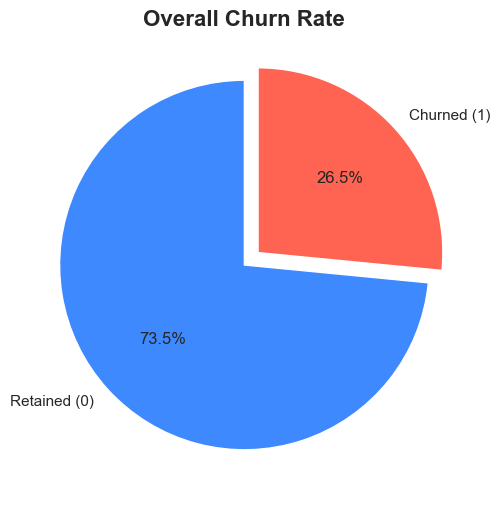

In [4]:
plt.figure(figsize=(6, 6))
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts, labels=['Retained (0)', 'Churned (1)'], autopct='%1.1f%%', 
        startangle=90, colors=["#3f89ff", "#ff6352"], explode=(0, 0.1))
plt.title('Overall Churn Rate', fontsize=16, fontweight='bold')
plt.show()

### Data Insight & Modeling Implications

- Churn rate is ~26.5%, indicating a significant retention issue.

- The dataset shows moderate class imbalance.

- A naive model can achieve ~73.5% accuracy by predicting no churn, 
  making accuracy an unreliable metric.

→ Focus will be on Recall, F1-score, and PR-AUC.

→ Class imbalance handling (e.g., class weighting or SMOTE) will be considered.

## 4. Demographics Analysis

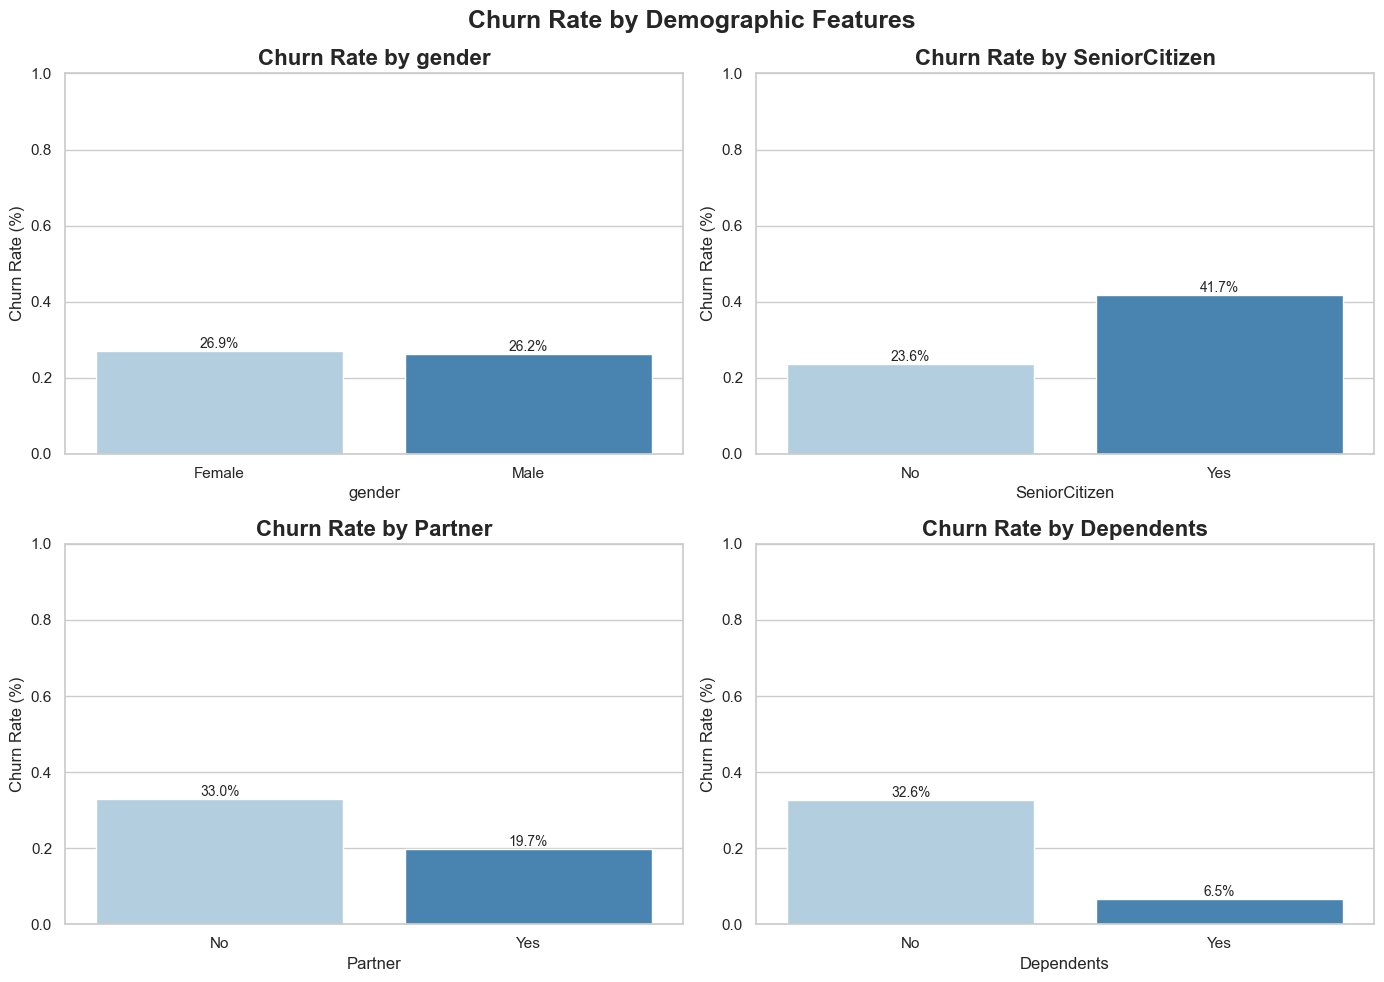

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
demo_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
fig.suptitle('Churn Rate by Demographic Features', fontsize=18, fontweight='bold', y=0.98)

for i, col in enumerate(demo_features):
    ax = axes[i//2, i%2]
    
    # Calculate churn rate (%)
    temp = df.groupby(col)['Churn'].mean().reset_index()
    
    sns.barplot(data=temp, x=col, y='Churn', palette='Blues', ax=ax)
    
    # Convert to percentage
    ax.set_ylabel('Churn Rate (%)')
    ax.set_title(f'Churn Rate by {col}', fontsize=16, fontweight='bold')
    ax.set_ylim(0, 1)

    # Annotation %
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height*100:.1f}%',
                    (p.get_x() + p.get_width()/2., height),
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Demographic Insights
- **Gender:** Churn rates are nearly identical across genders, 
  indicating gender is not a meaningful factor in customer churn.

- **Senior Citizens:** Senior customers exhibit significantly higher churn rates, 
  suggesting they may face usability, pricing, or support-related challenges.

- **Partner Status:** Customers without a partner have higher churn rates, 
  indicating that less socially or financially anchored customers are more likely to leave.

- **Dependents:** Customers without dependents show substantially higher churn rates, 
  while those with dependents are more stable, likely due to higher switching costs and long-term service needs.

→ Retention efforts should prioritize **senior customers and individuals without family ties**, 
  as these groups are more vulnerable to churn.

→ Developing **family-oriented plans or bundled services** may help increase customer stickiness 
  and reduce churn risk.

## 5. Services Usage Analysis
### 5.1. Big Picture: Feature Correlation
Before diving into each specific service, we need to first take an overall view to identify which features have the strongest correlation with customer churn.

This chart will show that certain service groups (such as TechSupport and OnlineSecurity) rank among the top in reducing churn. From there, it opens up a direction for deeper analysis into the Service category.

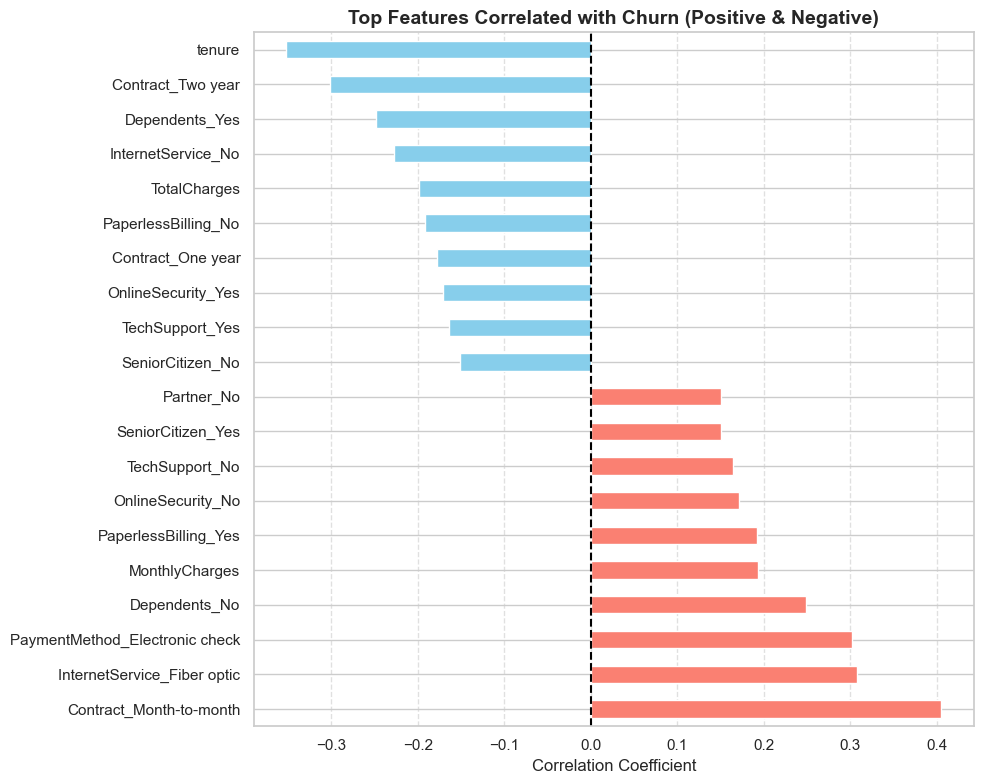

In [6]:
# Create dummy variables for categorical features, not including 'CustomerID' (as it's an identifier)
df_dummies = pd.get_dummies(df.drop(columns=['customerID'], errors='ignore'))

# Calculate the correlation matrix and drop the target variable from the correlation matrix to focus on feature correlations
corr_with_target = df_dummies.corr()['Churn'].drop('Churn').sort_values(ascending=False)
top_corr = pd.concat([corr_with_target.head(10), corr_with_target.tail(10)])

plt.figure(figsize=(10, 8))
top_corr.plot(kind='barh', color=['salmon' if x > 0 else 'skyblue' for x in top_corr])

plt.title('Top Features Correlated with Churn (Positive & Negative)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 5.2 Individual Service Analysis
>  Does the *type* of core connection (Internet/Phone) or the presence of specific add-on services (like Tech Support or Security) influence the customer's decision to stay or leave?

#### Service Categories

**Core Services**
- `PhoneService`: Basic phone service  
- `InternetService`: Basic internet service  

**Phone Add-ons**
- `MultipleLines`: Multiple phone lines (typically included if PhoneService is active)  

**Security & Support Add-ons (Most Critical Group)**
- `OnlineSecurity`: Online security  
- `OnlineBackup`: Online backup  
- `DeviceProtection`: Device protection  
- `TechSupport`: Technical support  

> This group is often the **key driver of customer retention**, as it creates the strongest switching costs.

**Entertainment Add-ons**
- `StreamingTV`: TV streaming service  
- `StreamingMovies`: Movie streaming service  

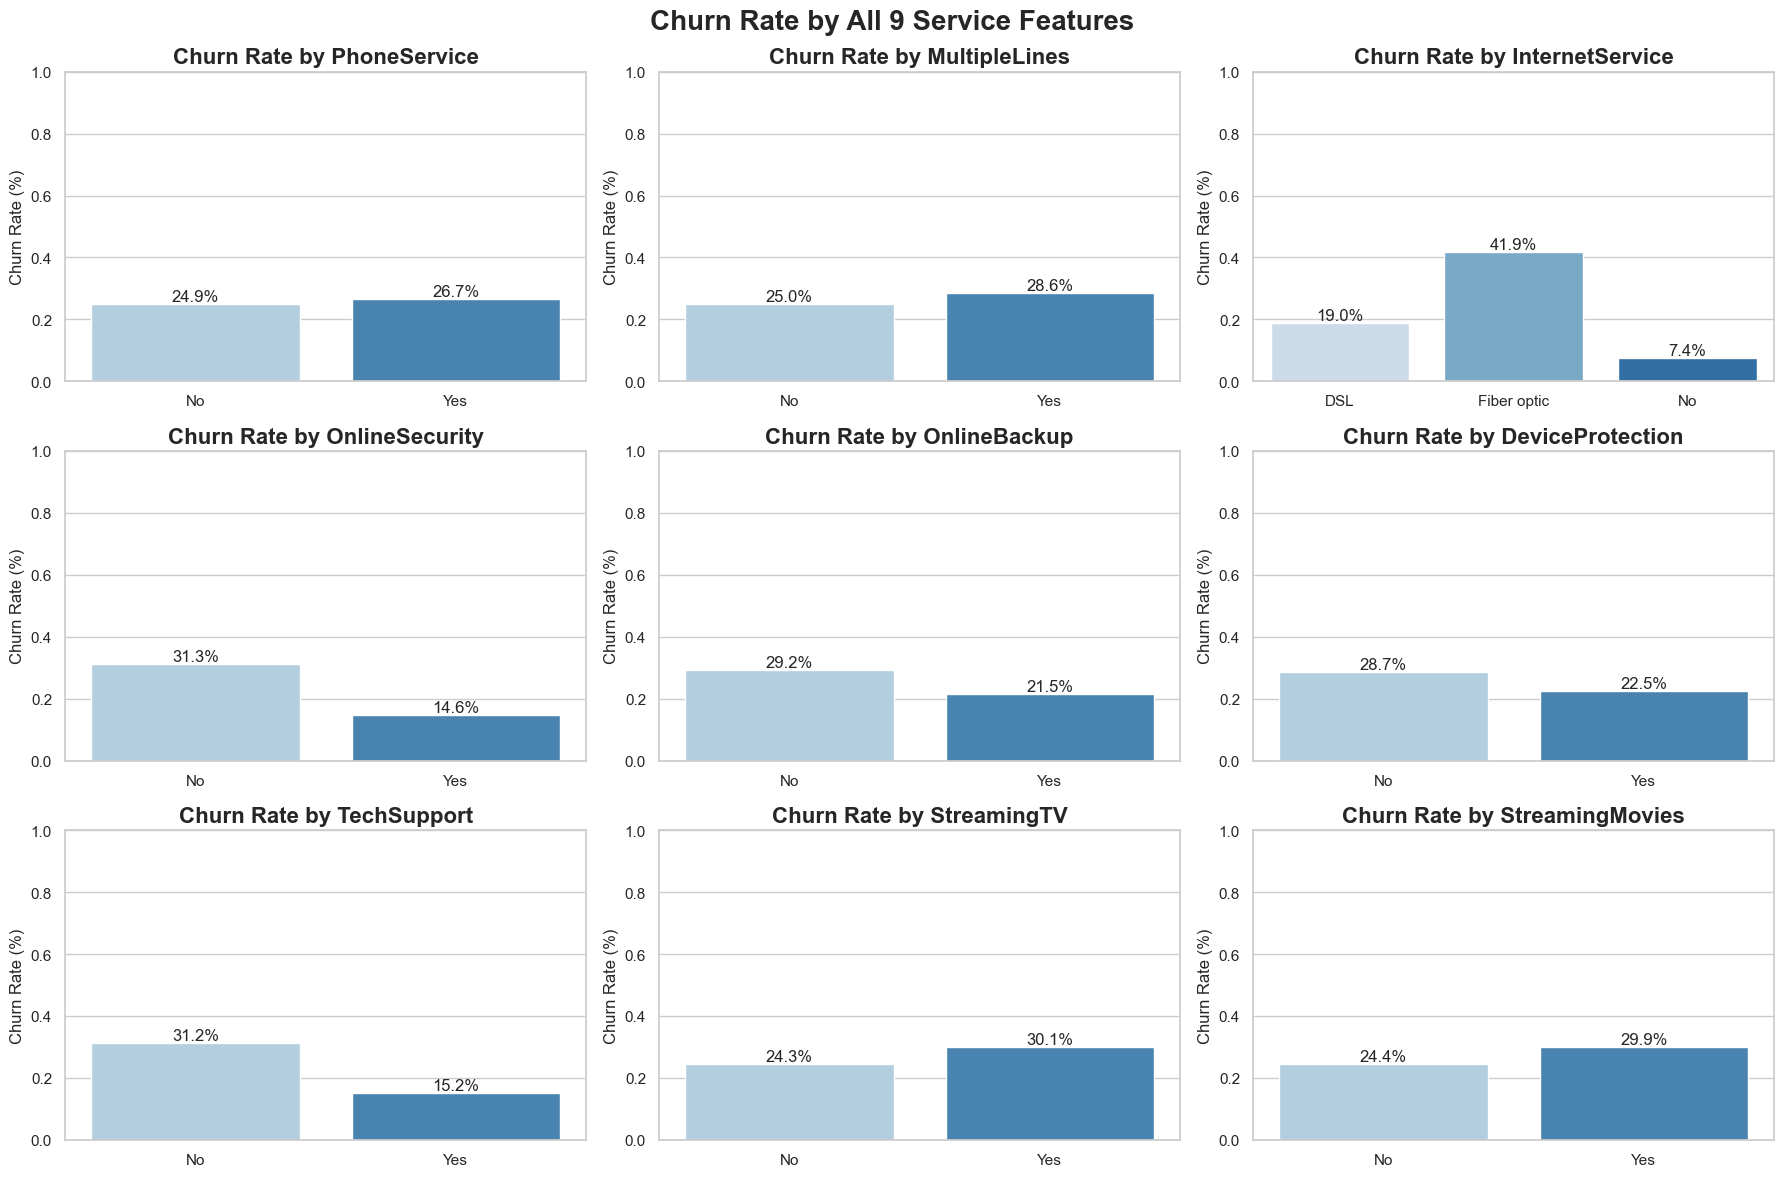

In [7]:
services_all = [
    'PhoneService', 'MultipleLines', 'InternetService',  # Row 1: Core & Phone
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', # Row 2: Security 
    'TechSupport', 'StreamingTV', 'StreamingMovies'       # Row 3: Support & Entertainment
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Churn Rate by All 9 Service Features', fontsize=20, fontweight='bold', y=0.98)

for i, col in enumerate(services_all):
    ax = axes[i//3, i%3]
    
    # Calculate churn rate (%)
    temp = df.groupby(col)['Churn'].mean().reset_index()
    
    sns.barplot(data=temp, x=col, y='Churn', palette='Blues', ax=ax)
    
    # Convert to percentage
    ax.set_ylabel('Churn Rate (%)')
    ax.set_title(f'Churn Rate by {col}', fontsize=16, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_xlabel('')  # Remove x-axis label for cleaner look

    # Annotation %
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height*100:.1f}%',
                    (p.get_x() + p.get_width()/2., height),
                    ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

### Key Insights from Service Analysis

**Security & Support Add-ons:**

- Customers who do **not** have OnlineSecurity, TechSupport, OnlineBackup, and DeviceProtection exhibit a significantly higher churn rate.  

- This strongly supports the hypothesis: customers who only subscribe to **bare Internet service (without protective add-ons)** are highly likely to churn.

**Entertainment Add-ons:**

- StreamingTV and StreamingMovies do **not** create a strong switching barrier compared to the Security & Support group.  

- These services provide value, but they are **not critical enough** to significantly improve customer retention.

**Bundling Feature (Next – Section 5.3):**

- At this stage, the `total_services_count` feature (constructed using 7 add-on variables: MultipleLines + 6 Internet add-ons) becomes highly meaningful.  

- This is because the analysis has already examined each individual service, allowing the bundling feature to serve as a *consolidated representation of overall service adoption behavior*.

### 5.3 Service Bundling Effect
After looking at individual services in isolation, a more strategic perspective is to evaluate the total number of services a customer uses.

> "Does using more services (service bundling) make customers more loyal, or more likely to churn?"

To answer this, we will create a new feature called total_services_count and group customers accordingly to uncover meaningful patterns.

In [8]:
# Helper function to plot churn rate
def plot_churn_rate(data, feature, title, ax):
    churn_rate = data.groupby(feature)['Churn'].value_counts(normalize=True).unstack()

    churn_rate[1].plot(
        kind='bar',
        color='lightblue',
        edgecolor='black',
        ax=ax
    )

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel("Churn Rate (%)")
    ax.set_xlabel(feature)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')

    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.1%}",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='center',
            xytext=(0, 8),
            textcoords='offset points',
            fontweight='bold'
        )

    ax.set_ylim(0, churn_rate[1].max() + 0.1)

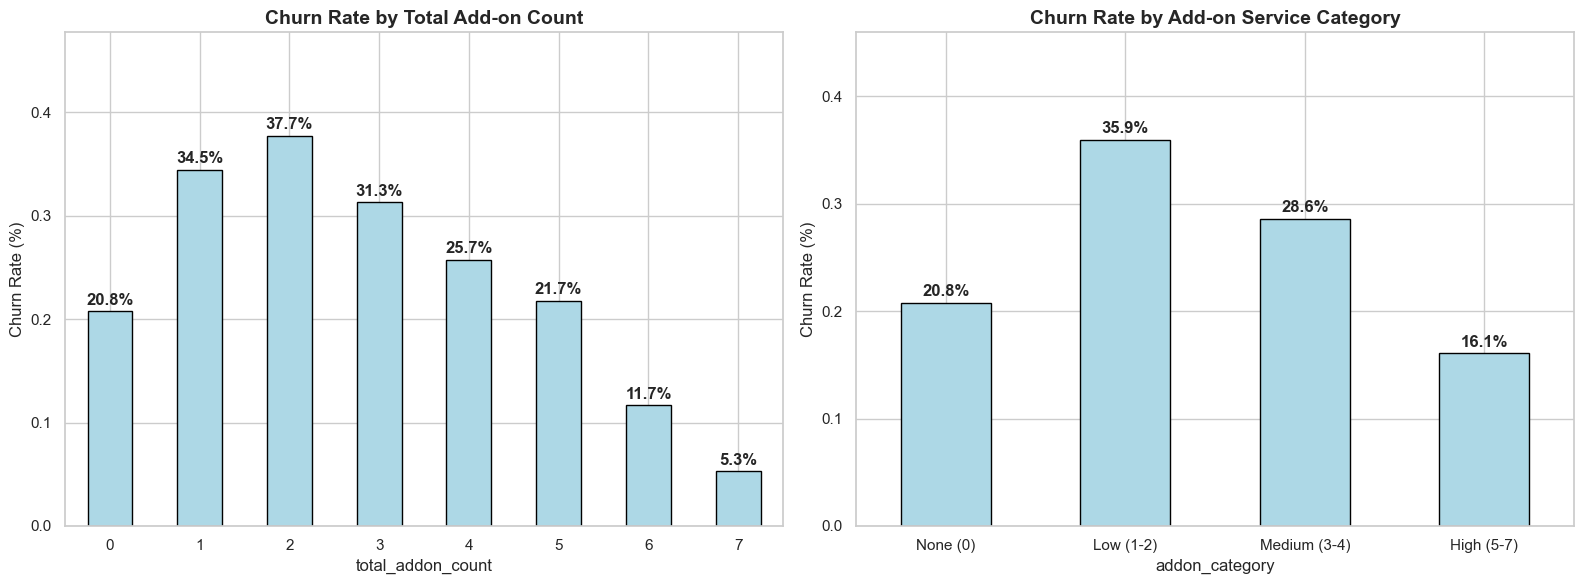

In [9]:
# Define add-on services - Exclude core services
addon_services = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Create a feature that counts the number of add-on services used by each customer
df['total_addon_count'] = df[addon_services].apply(lambda x: (x == 'Yes').sum(), axis=1)

# Categorize (bin) the level of total_addon_count into groups
df['addon_category'] = pd.cut(df['total_addon_count'], bins=[-1, 0, 2, 4, 7], labels=['None (0)', 'Low (1-2)', 'Medium (3-4)', 'High (5-7)'])

# Plot churn rate by add-on service category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_churn_rate(df, 'total_addon_count', 'Churn Rate by Total Add-on Count', ax=axes[0])
plot_churn_rate(df, 'addon_category', 'Churn Rate by Add-on Service Category', ax=axes[1])
plt.tight_layout()
plt.show()


#### *Add-on Segmentation Strategy*

This segmentation reveals a non-linear relationship between add-on adoption and churn, highlighting distinct behavioral segments:

**The “None” Paradox (0 add-ons):**
- Customers with no add-ons exhibit a surprisingly low churn rate (~7.4%). This does not imply that add-ons drive churn; rather, this segment likely represents phone-only, low-cost users with minimal needs and low exposure to competitive switching triggers.

**The “Low (1–2)” Risk Zone:**
- This is *the most vulnerable segment*. Notably, customers with exactly one add-on show the highest churn rate in the dataset (up to 45.4%).
- This suggests a *fragile engagement state*, where customers have begun adopting additional services but have not yet developed strong dependency, making them highly sensitive to price, service issues, or competitor offers.

**Bundling Effect (3+ add-ons):**
Churn decreases sharply as the number of services increases:

- **Medium (3–4):** ~17.6%

- **High (5+):** ~6.4%

This confirms a strong switching cost effect, where deeper integration into the service ecosystem significantly improves retention.

#### *Strategic Implication*

- Rather than focusing on selling individual services, the business should prioritize a *“Cross-sell to 3+”* strategy.

- The threshold of 3 services acts as a tipping point, where customers transition from a trial/low-commitment state to a high-retention, high-value segment.

- Driving customers from the “Low” to “Medium” tier should be the primary objective, as it delivers the highest marginal impact on churn reduction.


## 6. Contract Type, Billing Analysis and Payment Method
### 6.1 Contract Type

In [10]:
# Crosstab analysis between 'Contract' and 'Churn'
ct_contract = pd.crosstab(
    df['Contract'], 
    df['Churn'], 
    normalize='index'
).round(3)

ct_contract.columns = ['No Churn', 'Churn']
ct_contract

,No Churn,Churn
Contract,,
Month-to-month,0.573,0.427
One year,0.887,0.113
Two year,0.972,0.028


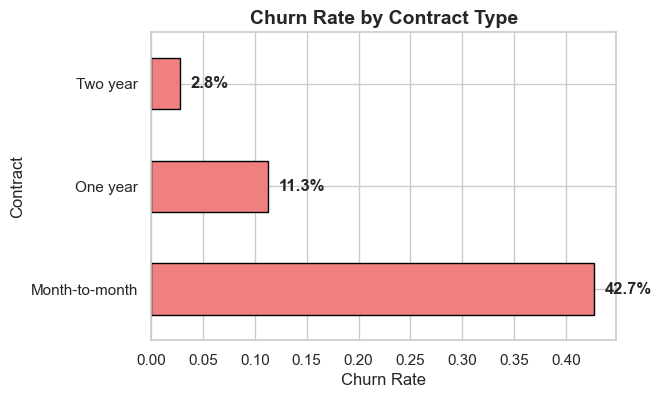

In [11]:
# Plot
ct_contract['Churn'] = ct_contract['Churn'].sort_values()
ct_contract['Churn'].plot(kind='barh', figsize=(6,4), color='lightcoral', edgecolor='black')
# Add percentage labels
for i, (index, value) in enumerate(ct_contract['Churn'].items()):
    plt.text(value + 0.01, i, f'{value:.1%}', va='center', fontweight='bold')

plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Churn Rate')
plt.show()

- **Month-to-month** contracts show the highest churn rate (~45%), 
  significantly higher than **one-year** (~12%) and **two-year** (~3%).

- This suggests that customers with shorter commitment periods 
  are much more likely to leave.

- Long-term contracts act as a strong retention mechanism.

### 6.2 Billing Analysis

In [12]:
ct_paper = pd.crosstab(
    df['PaperlessBilling'], 
    df['Churn'], 
    normalize='index'
).round(3)

ct_paper.columns = ['No Churn', 'Churn']
ct_paper

,No Churn,Churn
PaperlessBilling,,
No,0.837,0.163
Yes,0.664,0.336


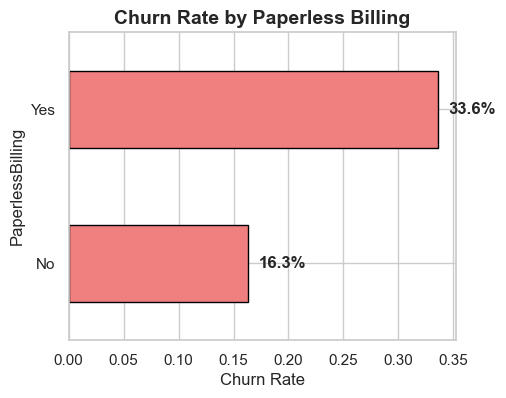

In [13]:
ct_paper['Churn'].plot(kind='barh', figsize=(5,4), color='lightcoral', edgecolor='black')
for i, (index, value) in enumerate(ct_paper['Churn'].items()):
    plt.text(value + 0.01, i, f'{value:.1%}', va='center', fontweight='bold')
    
plt.title('Churn Rate by Paperless Billing', fontsize=14, fontweight='bold')
plt.xlabel('Churn Rate')
plt.show()

- Customers using paperless billing have a higher churn rate 
  compared to those who do not.

- This may indicate that paperless users are more digitally engaged 
  but also more flexible and willing to switch providers.

### 6.3 Payment Method Analysis

In [14]:
ct_payment = pd.crosstab(
    df['PaymentMethod'], 
    df['Churn'], 
    normalize='index'
).round(3)

ct_payment.columns = ['No Churn', 'Churn']
ct_payment

,No Churn,Churn
PaymentMethod,,
Bank transfer (automatic),0.833,0.167
Credit card (automatic),0.848,0.152
Electronic check,0.547,0.453
Mailed check,0.809,0.191


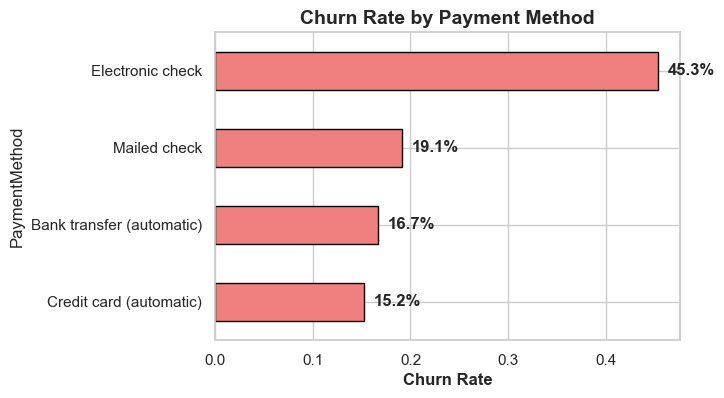

In [15]:
ct_payment['Churn'].sort_values().plot(kind='barh', figsize=(6,4), color='lightcoral', edgecolor='black')

for i, (index, value) in enumerate(ct_payment['Churn'].sort_values().items()):
    plt.text(value + 0.01, i, f'{value:.1%}', va='center', fontweight='bold')
    
plt.title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Churn Rate', fontsize=12, fontweight='bold')
plt.show()

- Customers using electronic check exhibit the highest churn rate.

- In contrast, customers using automatic payment methods 
  (credit card or bank transfer) tend to have lower churn rates.

- This suggests that automated payments may be associated 
  with higher customer retention.
  

## 7. Charges and Tenure Analysis
In this section, we analyze how customer **tenure** and **billing characteristics** relate to churn behavior. These variables are critical for understanding **customer value, lifecycle stage, and pricing sensitivity**.

Specifically, we aim to answer the following questions:

- Are **new customers** more likely to churn compared to long-term customers?
- Does a **higher monthly cost** increase the likelihood of churn?
- How does **total spending over time** relate to customer retention?
- Can we identify **high-risk segments** based on tenure and charges?

By exploring these dimensions, we can better understand **when churn happens** in the customer lifecycle and **which type of customers are most at risk**, providing valuable insights for retention strategies.

In [16]:
# Helper Functions for distribution plots
def plot_distribution(df, col, ax, title):
    sns.histplot(
            data=df, 
            x=col, 
            hue='Churn', 
            kde=True, 
            palette='Set1', 
            alpha=0.5, 
            ax=ax
        )
    ax.set_title(title, fontsize=13, fontweight='bold')

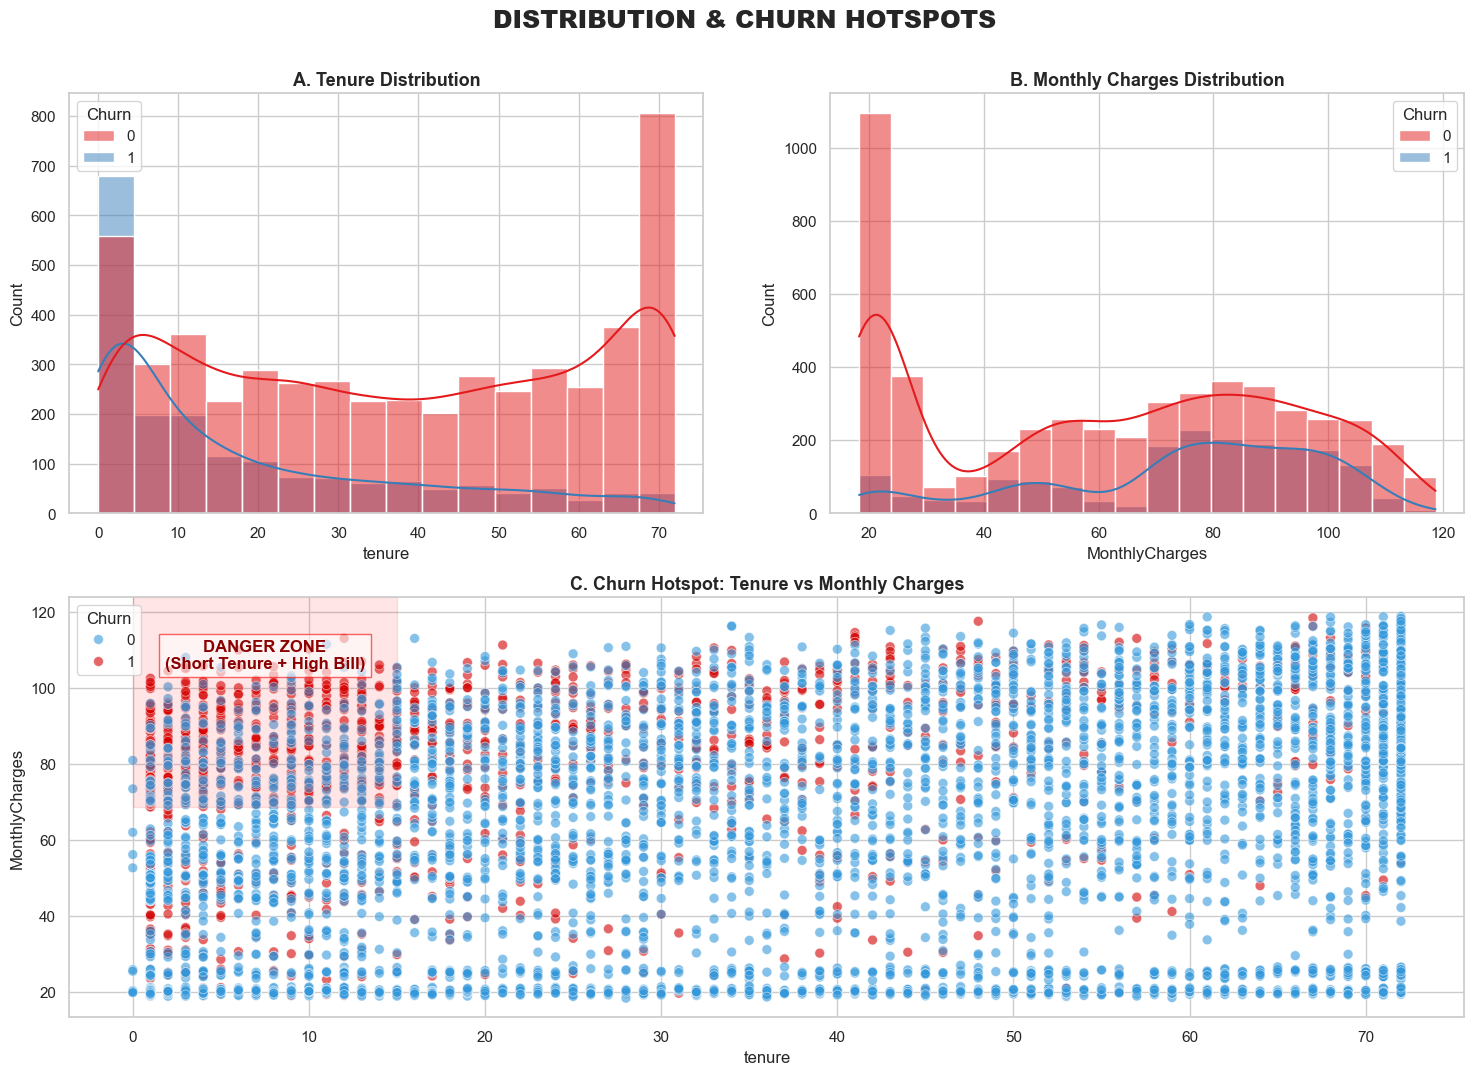

In [17]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('DISTRIBUTION & CHURN HOTSPOTS', fontsize=18, fontweight='black', y=0.95)

# Row 1: Distribution
ax1 = plt.subplot(2, 2, 1)
plot_distribution(df, 'tenure', ax1, 'A. Tenure Distribution')

ax2 = plt.subplot(2, 2, 2)
plot_distribution(df, 'MonthlyCharges', ax2, 'B. Monthly Charges Distribution')

# Row 2: Hotspot
ax3 = plt.subplot(2, 1, 2)

sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue='Churn',
    palette=['#3498db', "#d20000"],
    alpha=0.6,
    s=50,
    ax=ax3
)

# Highlight danger zone
ax3.axvspan(0, 15, ymin=0.5, ymax=1, color='red', alpha=0.1)
ax3.text(
    7.5, 105,
    'DANGER ZONE\n(Short Tenure + High Bill)',
    color='darkred',
    fontsize=12,
    fontweight='bold',
    ha='center',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='red')
)

ax3.set_title('C. Churn Hotspot: Tenure vs Monthly Charges', fontsize=13, fontweight='bold')

plt.tight_layout(rect=(0.0, 0.0, 0.0, 0.95))
plt.show()

#### Key Insights:

- **Early-stage churn is highly concentrated:** Customers with very short tenure show a significantly higher density of churn, indicating that churn risk is most critical during the early lifecycle stage.

- **Pricing pressure contributes to churn:** Customers with higher monthly charges are more likely to churn, suggesting sensitivity to pricing or perceived lack of value.

- **Clear churn hotspot identified:** A high-risk “danger zone” emerges where customers have both **low tenure and high monthly charges**. This segment represents customers who have not yet built loyalty but are already exposed to high costs.

- **Retention stabilizes over time:** As tenure increases, churn becomes less frequent, indicating that long-term customers are more stable and loyal.

**Implication:** The first 6–12 months represent a critical window where customer experience and perceived value must be optimized to prevent early churn.

## 8. Customer Segementation


### 8.1 Univariate Segmentation

In [18]:
# Tenure segmentation (Loyalty)
df['Tenure_Group'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-1 Year', '1-2 Years', '2-4 Years', '4-6 Years']
)

# Monthly Charges segmentation (Spending)
df['Charge_Group'] = pd.qcut(
    df['MonthlyCharges'],
    q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)

# Effective monthly cost
df['AvgCharges_Per_Month'] = df['TotalCharges'] / (df['tenure'] + 1e-5)

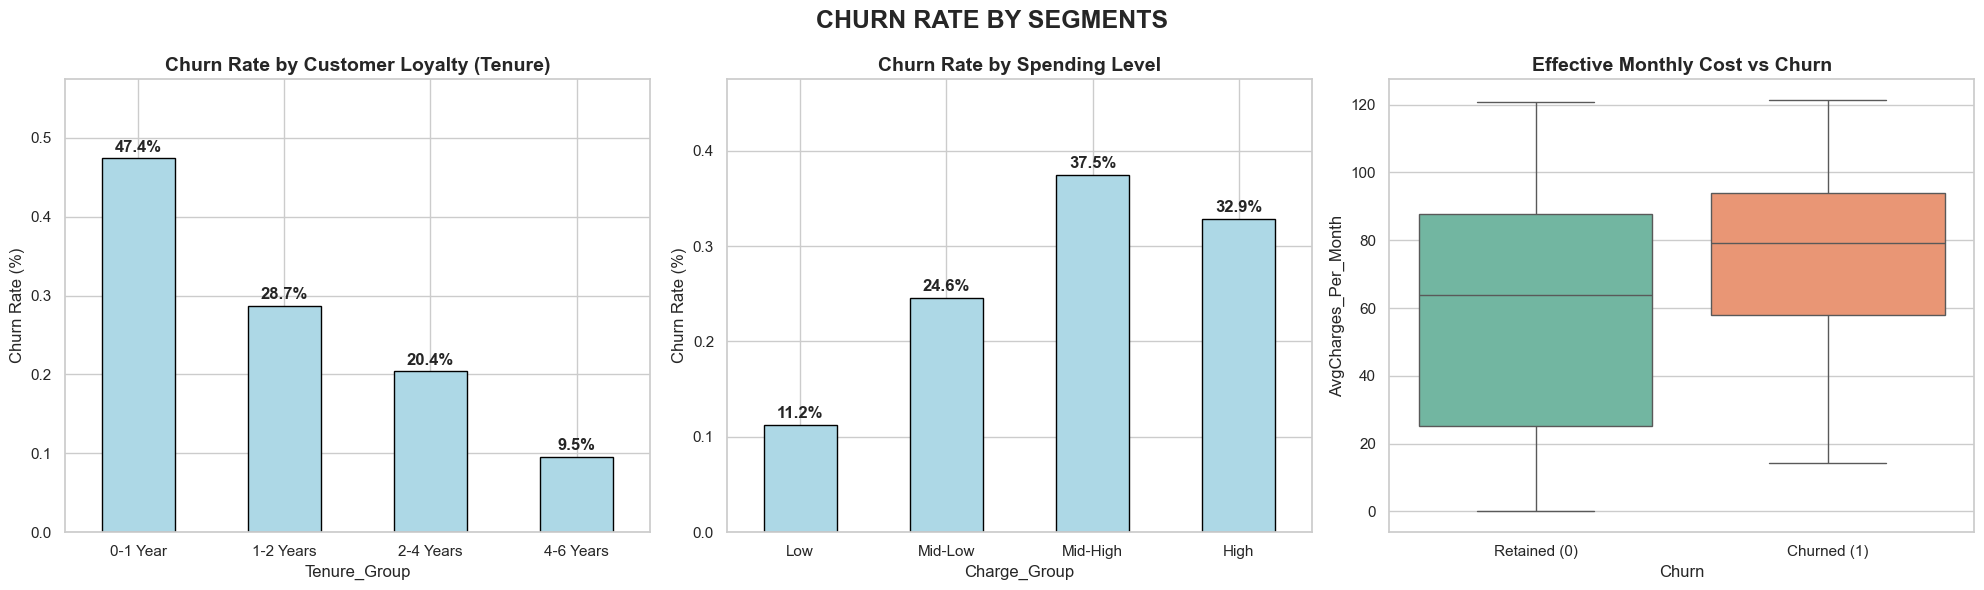

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('CHURN RATE BY SEGMENTS', fontsize=18, fontweight='bold')

# Tenure segmentation
plot_churn_rate(data=df, feature='Tenure_Group', title='Churn Rate by Customer Loyalty (Tenure)', ax=axes[0])

# Charges segmentation
plot_churn_rate(data=df, feature='Charge_Group', title='Churn Rate by Spending Level', ax=axes[1])

# Avg Charges (boxplot is kept separate due to different type)
sns.boxplot( data=df, x='Churn', y='AvgCharges_Per_Month', palette='Set2', ax=axes[2])

axes[2].set_title('Effective Monthly Cost vs Churn', fontsize=14, fontweight='bold')
axes[2].set_xticklabels(['Retained (0)', 'Churned (1)'])

plt.tight_layout()
plt.show()

#### Key Insights:

- **The “1-Year Trap” effect:** Customers in the **0–1 year tenure group** exhibit the highest churn rate by a large margin. Churn risk decreases significantly as customers stay longer, confirming that loyalty builds over time.

- **High spenders are more likely to churn:** Customers in the **highest monthly charge segment** show the highest churn rates, indicating that higher-paying customers are more sensitive to value mismatch.

- **Effective cost matters:** Customers who churn tend to have a higher **average monthly cost (AvgCharges per month)**, suggesting that perceived cost efficiency plays a key role in retention.

- **Low-value vs high-risk distinction:** Not all high-value customers are loyal — some high-paying customers with low tenure fall into a **high-risk segment**, reinforcing the importance of combining tenure and pricing factors.

 **Implication:** Retention strategies should focus on:
- Supporting new customers during their first year
- Ensuring pricing aligns with perceived value, especially for high-paying users
- Identifying and targeting high-risk segments (low tenure + high charges)



Both distribution analysis and segmentation consistently highlight a critical pattern:

> **Churn is most likely to occur when customers are early in their lifecycle and experience high pricing pressure.**

This suggests that churn is not driven by a single factor, but by the **interaction between customer maturity (tenure) and perceived cost (charges)**.

### 8.2  Cross Analysis (Multivariate Segmentation)

In this section, we extend our analysis by combining multiple features to uncover deeper churn patterns. 

Instead of analyzing each variable independently, we explore how **interactions between features** (e.g., contract type and pricing, or internet service and charges) influence churn behavior.

This helps identify more precise **high-risk customer segments** that may not be visible in single-variable analysis.

#### Contract and Monthly Charges


In [20]:
df['Charge_Group'].value_counts()

Charge_Group
Mid-Low     1766
Low         1762
High        1758
Mid-High    1757
Name: count, dtype: int64

In [21]:
contract_charge = pd.crosstab(
    df['Contract'],
    df['Charge_Group'],
    values=df['Churn'],
    aggfunc='mean'
)
contract_charge

Charge_Group,Low,Mid-Low,Mid-High,High
Contract,,,,
Month-to-month,0.250346,0.356177,0.532822,0.521839
One year,0.030457,0.086253,0.110687,0.208520
Two year,0.007752,0.024476,0.015528,0.070136


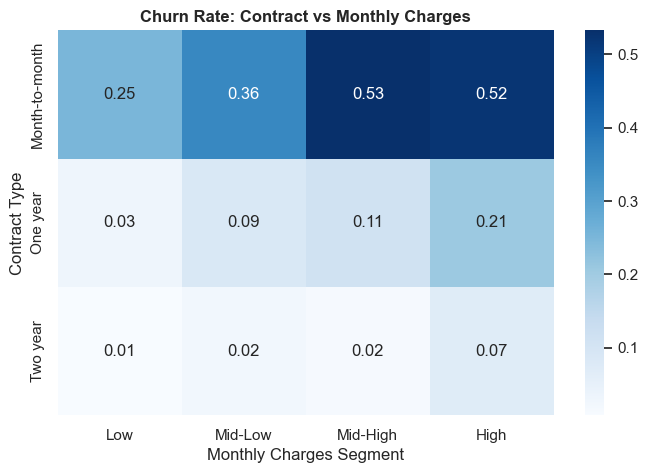

In [22]:
# Heatmap for Contract vs Monthly Charges
plt.figure(figsize=(8,5))

sns.heatmap(
    contract_charge,
    annot=True,
    fmt=".2f",
    cmap='Blues'
)

plt.title('Churn Rate: Contract vs Monthly Charges', fontweight='bold')
plt.ylabel('Contract Type')
plt.xlabel('Monthly Charges Segment')

plt.show()

#### Internet Service  and Charges

In [23]:
internet_charge = pd.crosstab(
    df['InternetService'],
    df['Charge_Group'],
    values=df['Churn'],
    aggfunc='mean'
)
internet_charge

Charge_Group,Low,Mid-Low,Mid-High,High
InternetService,,,,
DSL,0.360169,0.211215,0.064151,0.020000
Fiber optic,NaN,0.590062,0.509372,0.337822
No,0.074050,NaN,NaN,NaN


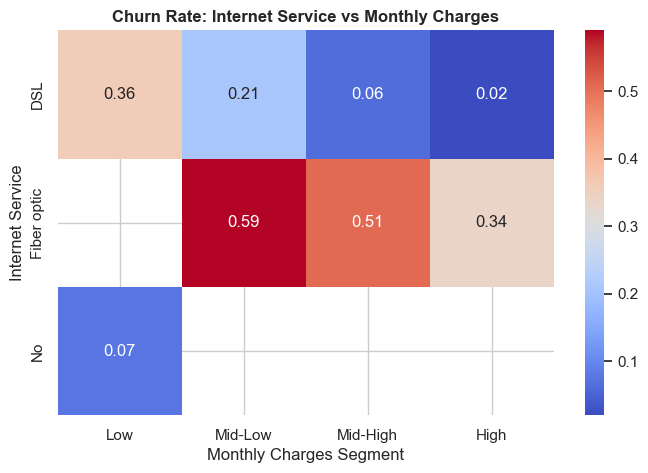

In [24]:
# Heatmap for Internet Service vs Monthly Charges
plt.figure(figsize=(8,5))

sns.heatmap(
    internet_charge,
    annot=True,
    fmt=".2f",
    cmap='coolwarm'
)

plt.title('Churn Rate: Internet Service vs Monthly Charges', fontweight='bold')
plt.ylabel('Internet Service')
plt.xlabel('Monthly Charges Segment')

plt.show()

### Key Insights: Cross Analysis

- **Contract effect dominates churn behavior:** Customers on **month-to-month contracts consistently show higher churn rates**, especially when combined with higher monthly charges.

- **Price sensitivity varies by contract type:** Long-term contracts (one-year, two-year) significantly reduce churn, even for customers in higher price segments.

- **Fiber optic customers show higher churn under high charges:** Among internet service types, **fiber optic users with high monthly charges exhibit elevated churn**, suggesting a mismatch between cost and perceived value.

- **Interaction effect is critical:** High churn is not driven by a single factor, but by the **combination of risk factors**, particularly:
  - Month-to-month contract + High charges
  - Fiber optic + High charges

 **Implication:** Target retention strategies should focus on specific combinations of features rather than individual variables alone.

## 9. Executive Summary & Business Recommendations

Following a comprehensive Exploratory Data Analysis (EDA) across various feature groups (Demographics, Services, Account, Usage), we have developed a clear picture of customer churn behavior in our Telco dataset. Below are the key takeaways and actionable insights.

### 9.1. Key Drivers of Churn

- **Contract Effect Dominates:** Customers on **month-to-month contracts exhibit overwhelmingly higher churn rates**. Conversely, long-term contracts (1-year, 2-year) significantly improve retention, even among customers in higher price segments.
- **Price Sensitivity & Value Perception:** A critical "danger zone" emerges where **high monthly charges intersect with Fiber Optic service**. This indicates that customers may feel the high cost does not justify the perceived quality or value of the fiber optic connection.
- **The 1-Year Trust Crisis:** New customers (tenure < 12 months) are at the highest risk of leaving. Once they surpass this 1-year threshold, customer loyalty and stability increase dramatically.
- **Interaction Effect is Critical:** Churn is rarely driven by a single isolated factor. It typically spikes when risk factors combine (e.g., Month-to-month contract + High charges + Fiber Optic service).

### 9.2. High-Risk Customer Profile
The Customer Success (CS) team should prioritize and closely monitor customers matching the following criteria:
1. **New users** with a tenure of less than 1 year.
2. Subscribed to a **Month-to-month contract**.
3. Using **Fiber Optic** internet but **lacking supplementary support/security services** (like TechSupport or OnlineSecurity).
4. Paying **High Monthly Charges**.

### 9.3. Strategic Recommendations

Based on the principle of *"targeting combinations of risk factors rather than single variables"*, we propose the following actions:

1. **Contract Conversion Strategy:** Incentivize month-to-month customers to switch to 1-year contracts by offering monthly discount rates or complimentary hardware upgrades.
2. **Ecosystem Bundling (Creating Switching Barriers):** Actively cross-sell `TechSupport` and `OnlineSecurity` to Fiber Optic customers. When customers rely on a broader ecosystem of protective services, their switching costs (and thus retention rates) increase significantly.
3. **Fiber Optic Quality Audit:** Share these findings with the Product and Technical teams to audit the actual performance and reliability of the Fiber Optic network compared to its pricing, addressing the root cause of dissatisfaction among high-paying users.

---
#### Next Step: From Insight to Prediction (Notebook 02)
Our Business EDA has successfully answered **"WHY"** customers churn. In the upcoming notebook (`02_Modeling.ipynb`), we will build a Machine Learning Pipeline to answer **"WHO"** is most likely to churn in the near future, enabling an automated Early Warning System for timely intervention.